# Pasos basicos para crear visualizaciones
1. Preparar los datos
2. Controlar la estetica de la figura
3. Graficar
4. Personalizar

In [1]:
#Librerias clasicas
import numpy as np
import pandas as pd
#Librerias de visualizacion
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar datos
df = sns.load_dataset('tips')
#Transformar en dataframe
df = pd.DataFrame(df)
df.head(3)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3


Descripción de datos: Este dataframe contiene caracteristicas de clientes de un restorant; 
total de la cuenta, propina, sexo, condicion de fumador, dia, tiempo de comida y tamaño de la mesa.

In [3]:
# Informacion de la tabla
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [4]:
# Resumen descriptivo
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
total_bill,244.0,19.79,8.90,3.07,13.35,17.8,24.13,50.81
tip,244.0,3.00,1.38,1.00,2.00,2.9,3.56,10.00
size,244.0,2.57,0.95,1.00,2.00,2.0,3.00,6.00


In [5]:
 df.describe(include='category').T

,count,unique,top,freq
sex,244,2,Male,157
smoker,244,2,No,151
day,244,4,Sat,87
time,244,2,Dinner,176


In [6]:
#Paso 2 : Controlar la estetica del grafico
sns.set_style('darkgrid')

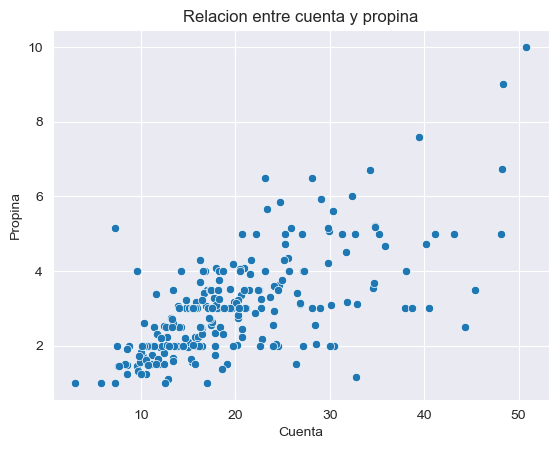

In [7]:
#Opcion 1
#Paso 3: Crear grafico diagrama de dispersion
sns.scatterplot(data=df, x='total_bill', y='tip')

#Paso 4:Personalizar
plt.title('Relacion entre cuenta y propina')
plt.xlabel('Cuenta')
plt.ylabel('Propina')
plt.show()

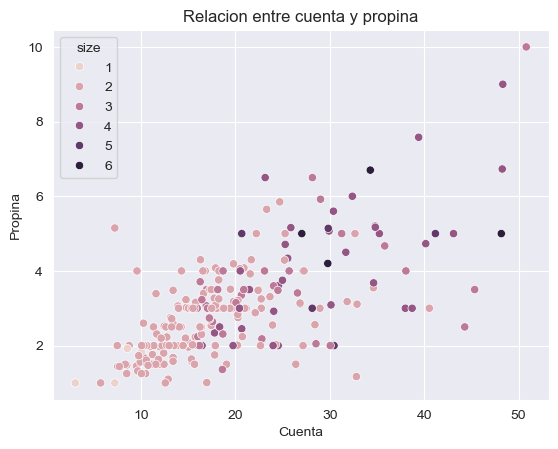

In [8]:
#Opcion 2
#Paso 3: Crear grafico diagrama de dispersion
g = sns.scatterplot(data=df, x='total_bill', y='tip', hue='size')

#Paso 4:Personalizar
g.set_title('Relacion entre cuenta y propina')
g.set_xlabel('Cuenta')
g.set_ylabel('Propina')
plt.show()

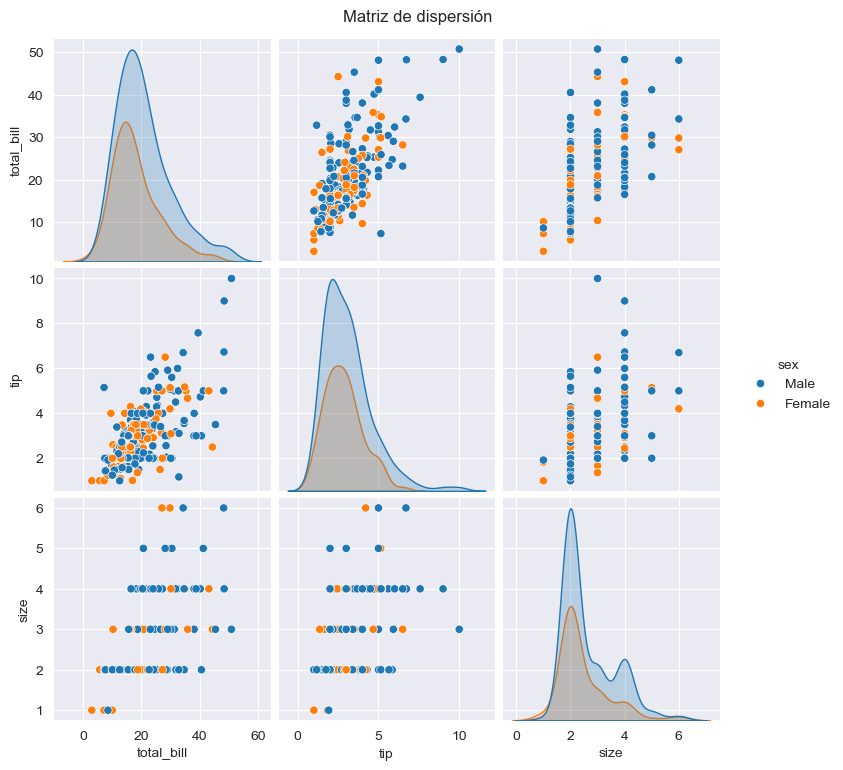

In [9]:
#Matriz de dispersión
g=sns.pairplot(df, hue='sex')
#Agregar titulo a la figura
g.fig.suptitle('Matriz de dispersión', y=1.02)
plt.show()

### Preguntas:
1. ¿Cuál es el tamaño promedio de los grupos que dan propinas?
2. ¿Cuál es el día de la semana con mayor cantidad total de propinas?
3. ¿Cómo varía la propina promedio entre los diferentes días de la semana?
4. ¿Cuál es la relación entre el total de la cuenta y la propina dada?
5. ¿Hay alguna diferencia notable en las propinas dadas por fumadores vs no fumadores?
6. ¿Qué porcentaje de las cuentas superan los 50 dólares?
7. ¿Cómo se distribuyen las facturas por género del pagador?
8. ¿Existe alguna correlación entre el tamaño del grupo y el porcentaje de la propina?
9. ¿Cuál es el tiempo (almuerzo o cena) con el promedio más alto de cuenta total?
10. ¿Cómo se distribuye el tamaño de las propinas en los diferentes días de la semana?
11. ¿Cuál es el máximo, mínimo y promedio de las cuentas por día de la semana?
12. ¿Cómo afecta el tamaño del grupo al total de la factura?
13. ¿Cuál es la propina más alta registrada y en qué circunstancias se dio?
14. ¿Qué porcentaje de las cuentas por día de la semana son de fumadores?
15. ¿Cómo afecta ser fumador o no al tamaño promedio del grupo?

In [10]:
#1. ¿Cuál es el tamaño promedio de los grupos que dan propinas?
len(df[df.tip>0]) #el tamaño de los grupos que dejaron propina es igual al espacio muestral
r1=df.groupby('size').tip.mean()
r1=r1.round(1)
r1=r1.reset_index()
r1=r1.rename(columns={'tip':'promedio'})
r1

,size,promedio
0,1,1.4
1,2,2.6
2,3,3.4
3,4,4.1
4,5,4.0
5,6,5.2


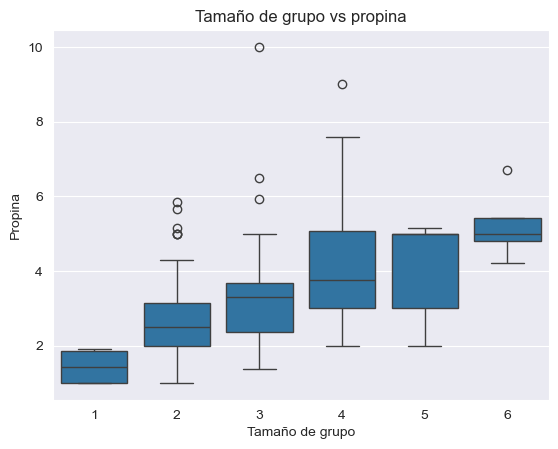

In [11]:
# El diagrama ideal para representar promedios son los boxplot o el diagrama de media
sns.boxplot(data=df, x='size', y='tip')
plt.title('Tamaño de grupo vs propina')
plt.xlabel('Tamaño de grupo')
plt.ylabel('Propina')
plt.show()

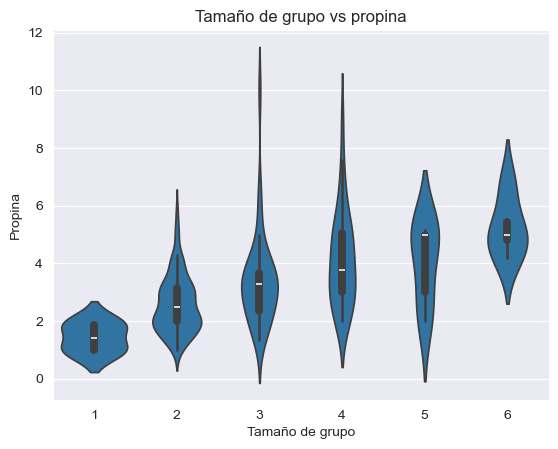

In [12]:
# grafico de violin/boxenplot
sns.violinplot(data=df, x='size', y='tip')
plt.title('Tamaño de grupo vs propina')
plt.xlabel('Tamaño de grupo')
plt.ylabel('Propina')
plt.show()

In [13]:
#2. ¿Cuál es el día de la semana con mayor cantidad total de propinas?
r2=df.groupby('day', observed=True).tip.sum()
print(f"El dia de la semana con mayor cantidad total de propinas es {r2.idxmax()} con un total de {r2.max()}")

El dia de la semana con mayor cantidad total de propinas es Sat con un total de 260.4


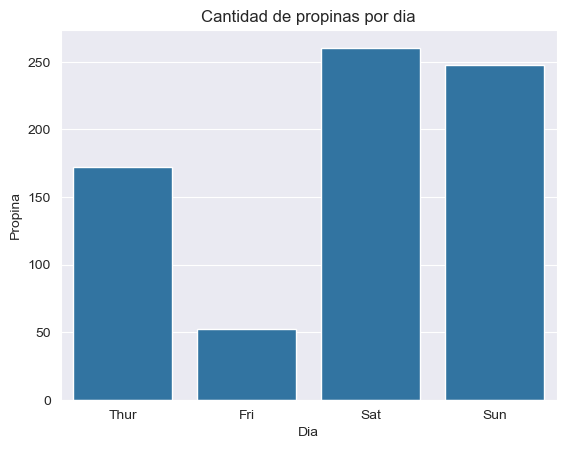

In [14]:
sns.barplot(r2)
plt.title('Cantidad de propinas por dia')
plt.xlabel('Dia')
plt.ylabel('Propina')
plt.show()

In [15]:
#3. ¿Cómo varía la propina promedio entre los diferentes días de la semana?
r3=df.groupby("day")["tip"].mean()
r3=r3.round(2)
r3=r3.reset_index()
print(f"Entre los diferentes dias de la semana la variacion de la propina es de {round(r3['tip'].std(),2)}")

Entre los diferentes dias de la semana la variacion de la propina es de 0.24


C:\Users\Alumno\AppData\Local\Temp\ipykernel_10896\1983763967.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  r3=df.groupby("day")["tip"].mean()


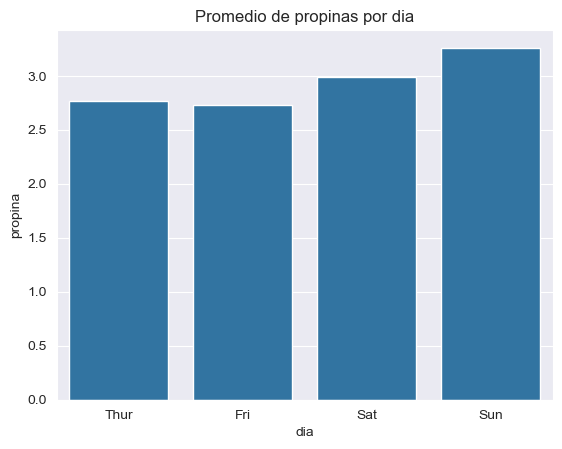

In [16]:
sns.barplot(data=r3, x='day', y='tip')
plt.title('Promedio de propinas por dia')
plt.xlabel('dia')
plt.ylabel('propina')
plt.show()

In [17]:
#4. ¿Cuál es la relación entre el total de la cuenta y la propina dada?
r4=df[["total_bill", "tip"]].corr()
print(f"La relacion entre el total de la cuenta y la propina es positiva con una intensidad de: {r4.iloc[0,1].round(2)}")

La relacion entre el total de la cuenta y la propina es positiva con una intensidad de: 0.68


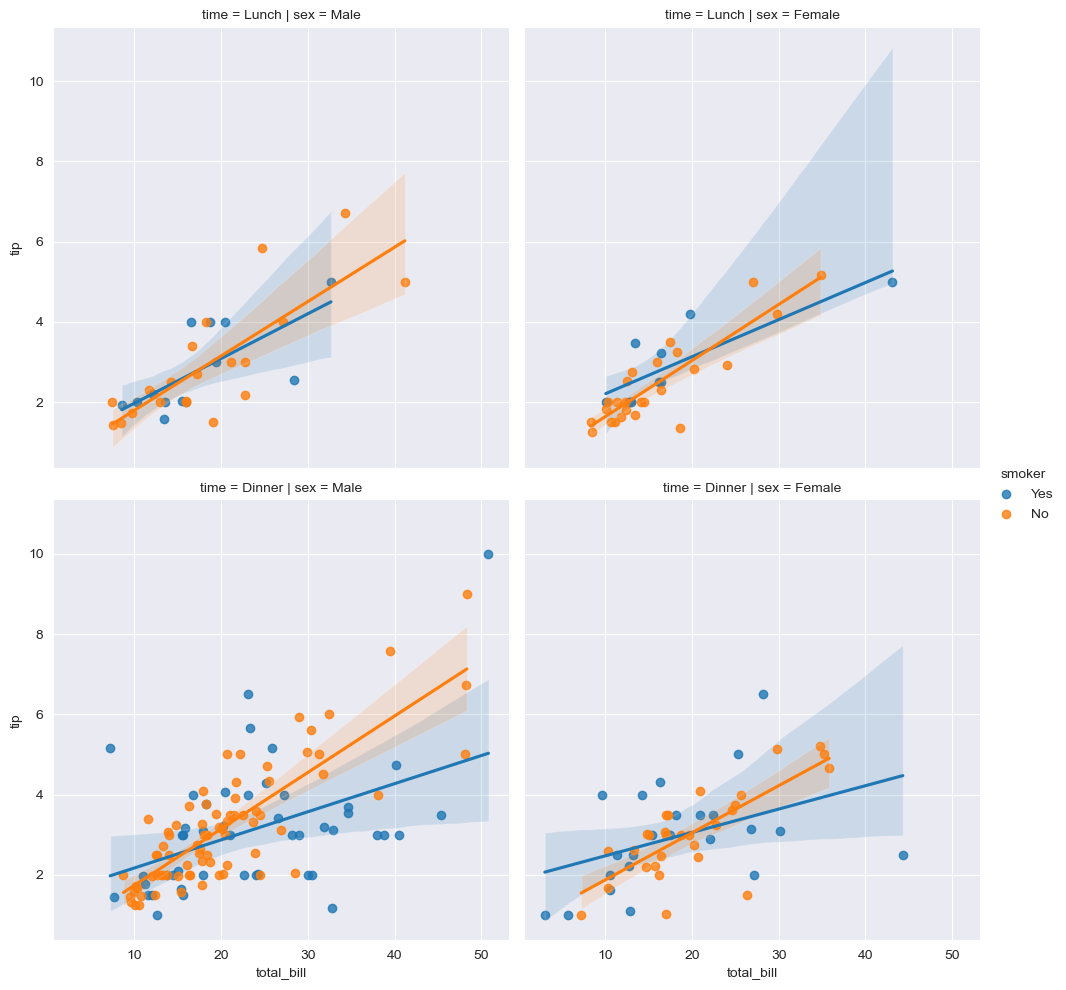

In [18]:
sns.lmplot(data=df, x='total_bill', y='tip', hue='smoker', col='sex', row='time')
"""plt.title("Relacion entre cuenta y propina")
plt.xlabel("Cuenta")
plt.ylabel("Propina")"""
plt.show()

In [19]:
#5. ¿Hay alguna diferencia notable en las propinas dadas por fumadores vs no fumadores?
r5=df.groupby("smoker")['tip'].mean()
r5=r5.round(2)
r5=r5.reset_index()
print(f"La diferencia entre las propinas dadas por fumadores vs no fumadores es {round(r5.iloc[0,1]-r5.iloc[1,1], 2)}")

La diferencia entre las propinas dadas por fumadores vs no fumadores es 0.02


C:\Users\Alumno\AppData\Local\Temp\ipykernel_10896\684485284.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  r5=df.groupby("smoker")['tip'].mean()


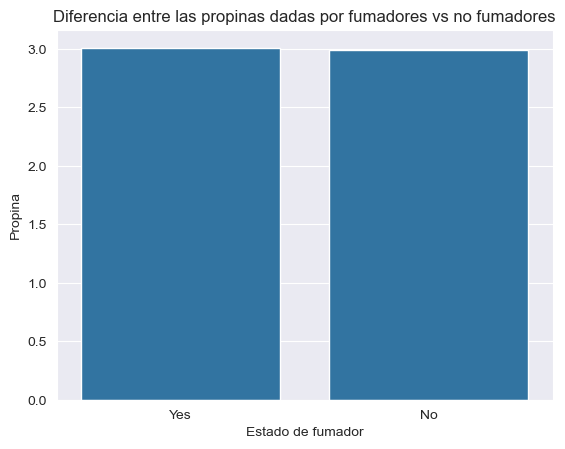

In [20]:
sns.barplot(data=r5, x='smoker', y='tip')
plt.title("Diferencia entre las propinas dadas por fumadores vs no fumadores")
plt.xlabel('Estado de fumador')
plt.ylabel('Propina')
plt.show()

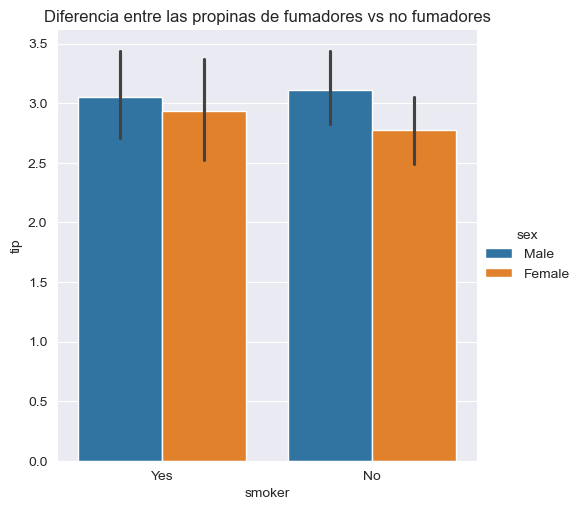

In [21]:
sns.catplot(data=df, x='smoker', y='tip', hue='sex', kind='bar')
plt.title("Diferencia entre las propinas de fumadores vs no fumadores")
plt.show()

In [22]:
#6. ¿}Qué porcentaje de las cuentas superan los 50 dólares?
df["pago mayor a 50"]=df["total_bill"]>50
mayor_50=(df["total_bill"]>50).mean()*100
contador=df["pago mayor a 50"].value_counts()

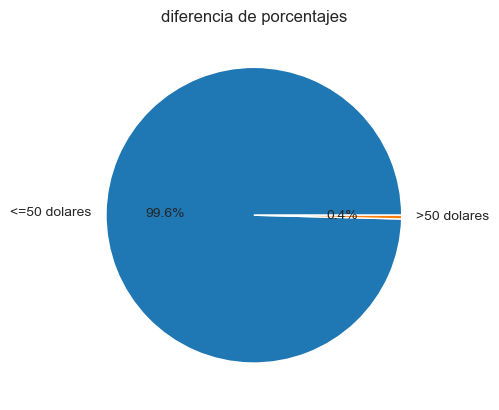

In [23]:
plt.pie(contador, labels=["<=50 dolares", ">50 dolares"], autopct="%1.1f%%")
plt.title("diferencia de porcentajes")
plt.show()